In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [2]:
from fkpwin.fkpwin import WindowMatrix

# BOSS window for power spectrum multipoles

In [3]:
ells = [0, 2]

BOSS power spectrum is measured in the following $k$-bins: 

In [4]:
Lbox, n0, dn = 3500., 3, 6
kf = 2 * np.pi / Lbox
nmax = dn * (np.floor(0.40/kf) // dn) - dn
kedges = np.arange(n0-dn//2, nmax+2*dn, dn) * kf
kcen = np.arange(n0,nmax+dn,dn) * kf
print (kedges.shape, kcen.shape)

(38,) (37,)


BOSS randoms power spectrum multipoles $Q_\ell(k)$

In [5]:
# z, red, sky = 0.57, "cmass", "ngc"
z, red, sky = 0.32, "lowz", "sgc"
kk, Q0, Q1, Q2, Q3, Q4 = np.loadtxt(os.path.join("..", "pre", "Qk", "Qk_n0_boss_%s_%s.dat") % (red, sky), unpack=True)
qk = np.array([Q0, 1j*Q1, Q2, 1j*Q3, Q4]) / Q0[0]
qk = qk[ells]

### window matrix computation

In [6]:
%%time
win = WindowMatrix(kedges=kedges, ells=ells, NFFT=1024)
win.set(qk, k=kk)
win.compute()
win.save_to(os.path.join('..', 'data', 'boss', 'wlmkp_boss_%s_%s') % (red, sky))

/Users/pierre/.pyenv/versions/3.11.9/lib/python3.11/site-packages/numpy/fft/_pocketfft.py:70: ComplexWarning: Casting complex values to real discards the imaginary part
  r = pfi.execute(a, is_real, is_forward, fct)


CPU times: user 4.91 s, sys: 186 ms, total: 5.1 s
Wall time: 5.7 s


/Users/pierre/.pyenv/versions/3.11.9/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/pierre/.pyenv/versions/3.11.9/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


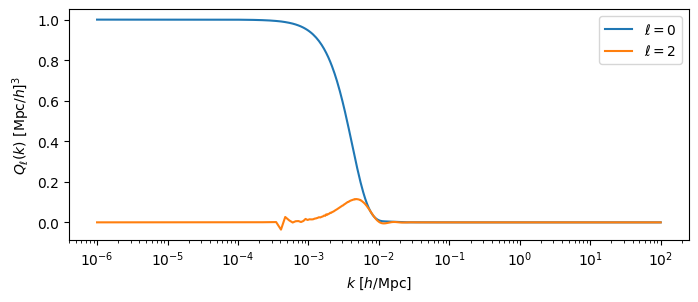

In [7]:
plt.figure(figsize=(8,3))
for i, ell in enumerate(ells): 
    plt.plot(kk, qk[i], 'C%s' % i, label=r'$\ell=%s$' % ell)
plt.ylabel(r'$Q_\ell(k) \ [{\rm Mpc}/h]^3$')
plt.xlabel(r'$k \ [h/{\rm Mpc}]$')
plt.xscale('log')
plt.legend()

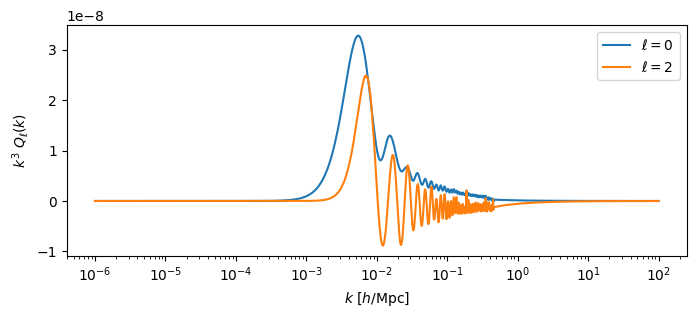

In [8]:
plt.figure(figsize=(8,3))
for i, ell in enumerate(ells): 
    plt.plot(kk, kk**3 * qk[i], 'C%s' % i, label=r'$\ell=%s$' % ell)
plt.ylabel(r'$k^3 \ Q_\ell(k)$')
plt.xlabel(r'$k \ [h/{\rm Mpc}]$')
plt.xscale('log')
plt.legend()

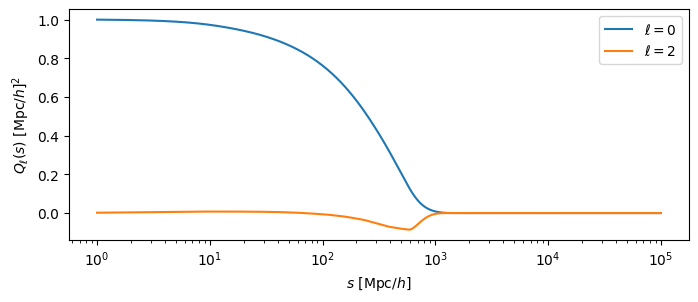

In [9]:
plt.figure(figsize=(8,3))
for i, ell in enumerate(ells): 
    plt.plot(win.s, win.qs[i], 'C%s' % i, label=r'$\ell=%s$' % ell)
plt.ylabel(r'$Q_\ell(s) \ [{\rm Mpc}/h]^2$')
plt.xlabel(r'$s \ [{\rm Mpc}/h]$')
plt.xscale('log')
plt.legend()

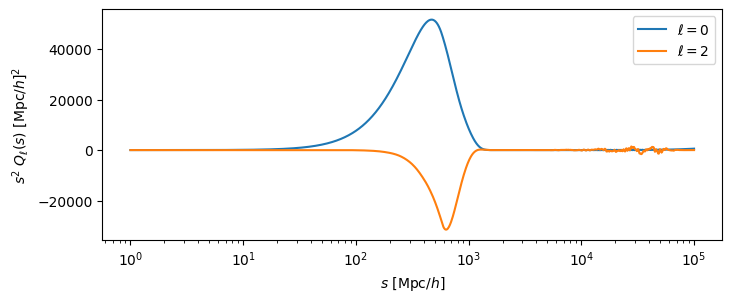

In [10]:
plt.figure(figsize=(8,3))
for i, ell in enumerate(ells): 
    plt.plot(win.s, win.s**2 * win.qs[i], 'C%s' % i, label=r'$\ell=%s$' % ell)
plt.ylabel(r'$s^2 \ Q_\ell(s) \ [{\rm Mpc}/h]^2$')
plt.xlabel(r'$s \ [{\rm Mpc}/h]$')
plt.xscale('log')
plt.legend()

Looks ok. Let's go production mode. 

In [11]:
%%time
for red in ['cmass', 'lowz']: 
    for sky in ['ngc', 'sgc']:
        kk, Q0, Q1, Q2, Q3, Q4 = np.loadtxt(os.path.join("..", "pre", "Qk", "Qk_n0_boss_%s_%s.dat") % (red, sky), unpack=True)
        qk = np.array([Q0, 1j*Q1, Q2, 1j*Q3, Q4]) / Q0[0]
        qk = qk[ells]
        win = WindowMatrix(kedges=kedges, ells=ells, NFFT=1024*16) # increased accuracy
        win.set(qk, k=kk)
        win.compute()
        win.save_to(os.path.join('..', 'data', 'boss', 'wlmkp_boss_%s_%s') % (red, sky))

CPU times: user 4min 55s, sys: 10.1 s, total: 5min 5s
Wall time: 5min 22s


### Testing

In [12]:
from classy import Class
from pybird.correlator import Correlator

Loading saved window

In [13]:
from fkpwin.utils import read
# z, red, sky = 0.57, "cmass", "ngc"
z, red, sky = 0.32, "lowz", "sgc"
survey_mask = read(os.path.join('..', 'data', 'boss', 'wlmkp_boss_%s_%s') % (red, sky))
k = survey_mask['p']

Linear cosmology

In [14]:
M = Class()
cosmo = {'omega_b': 0.02235, 'omega_cdm': 0.120, 'h': 0.675, 'ln10^{10}A_s': 3.044, 'n_s': 0.965}
M.set(cosmo)
M.set({'output': 'mPk', 'P_k_max_h/Mpc': 1, 'z_max_pk': z})
M.compute()

In [15]:
pk_lin = np.array([M.pk_lin(ki*M.h(), z)*M.h()**3 for ki in k]) 

Kaiser

In [16]:
mu = {
    0: {0: 1., 2: 0., 4: 0.},
    2: {0: 1. / 3., 2: 2. / 3., 4: 0.},
    4: {0: 1. / 5., 2: 4. / 7., 4: 8. / 35.},
}

In [17]:
b1, f1 = 1., M.scale_independent_growth_factor_f(z)

In [18]:
beta_l = np.array([b1**2 * mu[0][l] + 2*b1*f1*mu[2][l] + f1**2*mu[4][l] for l in ells])
pk = np.einsum('l,k->lk', beta_l, pk_lin)

Masked convolved power spectrum multipoles

In [19]:
wpk = np.einsum("lmkp,mp->lkp", survey_mask['wlmkp'], pk)
pk_c = np.trapz(wpk, x=k, axis=-1)

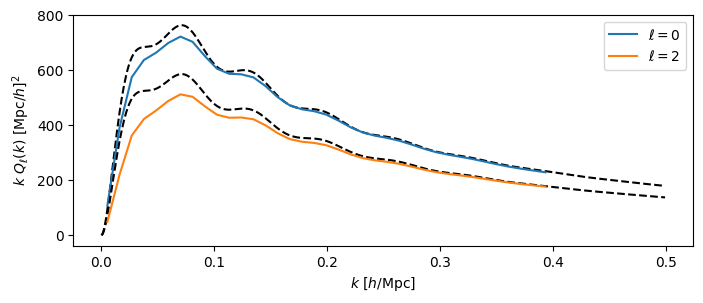

In [20]:
plt.figure(figsize=(8,3))
for i, ell in enumerate(ells): 
    plt.plot(k, k * pk[i], '--k')
    plt.plot(kcen, kcen * pk_c[i], 'C%s' % i, label=r'$\ell=%s$' % ell)
plt.ylabel(r'$k \ P_\ell(k) \ [{\rm Mpc}/h]^2$')
plt.xlabel(r'$k \ [h/{\rm Mpc}]$')
plt.legend()